# Clustering Test Notebook
Quick sanity check for all three clustering modules.

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pca import run_pca_pipeline
from clustering.clustering_kmeans import tune_kmeans, fit_kmeans, cluster_summary as km_summary
from clustering.clustering_hierarchical import fit_ward, fit_bisecting_kmeans, cluster_summary as h_summary
from clustering.clustering_density import tune_eps, fit_dbscan, cluster_summary as d_summary
from clustering.utils import plot_clustering, plot_cluster_averages, plot_neighbor_distances

In [83]:
# run pca pipeline — all clustering inputs come from here
results  = run_pca_pipeline()
X        = results['X_pca'].iloc[:, :results['n_components']]   # PC1, PC2, PC3
features = results['features_imp']                              # original 8 features (imputed)
meta     = results['meta']                                      # driver names etc.

3 component(s) needed to explain 94.1% of variance (threshold: 90%)


## 1 — K-Means

In [84]:
tune = tune_kmeans(X)
best_k = tune['multi_k_range'][np.argmax(tune['ch_mean'])]
print(f'Best k by CH score: {best_k}')

Best k by CH score: 4


In [85]:
_, km_labels, km_centers = fit_kmeans(X, k=best_k)
print('Cluster sizes:', dict(zip(*np.unique(km_labels, return_counts=True))))

Best seed: 0  |  Inertia: 104.9364
Cluster sizes: {np.int32(0): np.int64(23), np.int32(1): np.int64(5), np.int32(2): np.int64(30), np.int32(3): np.int64(19)}


In [86]:
km_summary(features, km_labels)

,avg_finish_position,avg_grid_position,avg_points_per_race,win_rate,podium_rate,dnf_rate,avg_fastest_lap_speed,avg_best_quali_time,n_drivers
Cluster 0,15.036249,15.976997,0.579736,0.000841,0.005178,0.760249,196.654895,92.395909,23
Cluster 1,6.466622,4.994049,9.408404,0.252126,0.477680,0.231961,206.067911,86.343443,5
Cluster 2,13.117548,13.376054,0.911960,0.001164,0.019572,0.707585,205.936468,86.444850,30
Cluster 3,9.086179,8.229412,5.147195,0.045847,0.206400,0.388094,206.564407,86.178582,19
Overall,12.264035,12.338722,2.409499,0.028389,0.091120,0.613596,203.327532,88.150152,77


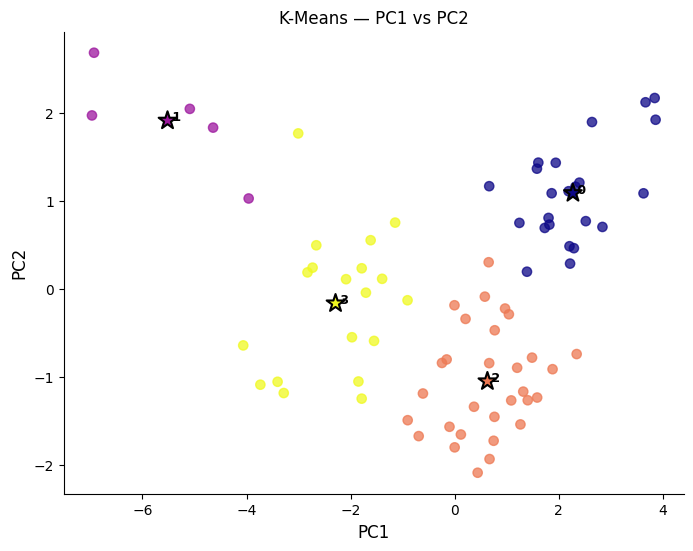

In [87]:
plot_clustering(X, 'PC1', 'PC2', km_labels, km_centers)
plt.title('K-Means — PC1 vs PC2')
plt.show()

(<Figure size 1000x500 with 1 Axes>, <Axes: >)

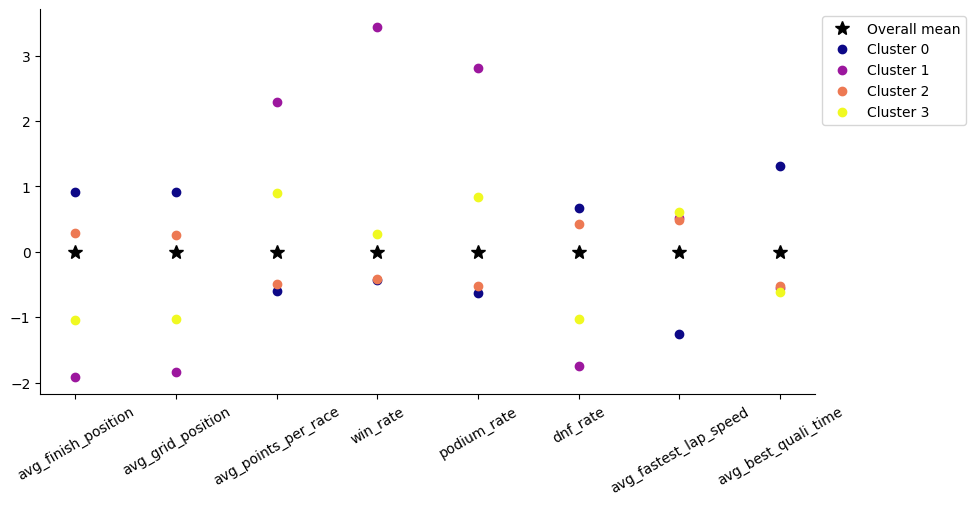

In [88]:
from sklearn.preprocessing import StandardScaler

X_plot = pd.DataFrame(
    StandardScaler().fit_transform(features),
    columns=features.columns
)
plot_cluster_averages(X_plot, km_labels)

## 2 — Hierarchical

In [89]:
Z, ward_labels, cophenetic = fit_ward(X, n_clusters=4)
print('Cluster sizes:', dict(zip(*np.unique(ward_labels, return_counts=True))))
print(f'Cophenetic correlation: {cophenetic:.4f}')

Cophenetic correlation (Ward): 0.6780
Cluster sizes: {np.int64(0): np.int64(5), np.int64(1): np.int64(30), np.int64(2): np.int64(19), np.int64(3): np.int64(23)}
Cophenetic correlation: 0.6780


In [90]:
h_summary(features, ward_labels)

,avg_finish_position,avg_grid_position,avg_points_per_race,win_rate,podium_rate,dnf_rate,avg_fastest_lap_speed,avg_best_quali_time,n_drivers
Cluster 0,6.466622,4.994049,9.408404,0.252126,0.477680,0.231961,206.067911,86.343443,5
Cluster 1,13.117548,13.376054,0.911960,0.001164,0.019572,0.707585,205.936468,86.444850,30
Cluster 2,9.086179,8.229412,5.147195,0.045847,0.206400,0.388094,206.564407,86.178582,19
Cluster 3,15.036249,15.976997,0.579736,0.000841,0.005178,0.760249,196.654895,92.395909,23
Overall,12.264035,12.338722,2.409499,0.028389,0.091120,0.613596,203.327532,88.150152,77


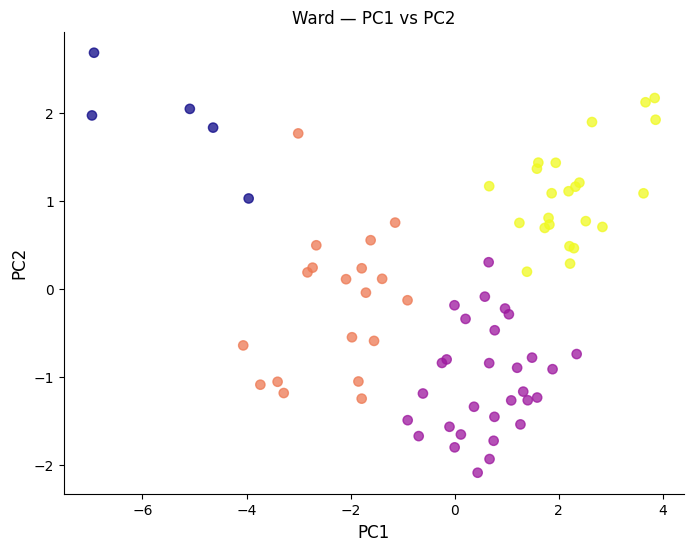

In [91]:
plot_clustering(X, 'PC1', 'PC2', ward_labels)
plt.title('Ward — PC1 vs PC2')
plt.show()

BKM sizes: {np.int32(0): np.int64(29), np.int32(1): np.int64(23), np.int32(2): np.int64(5), np.int32(3): np.int64(20)}


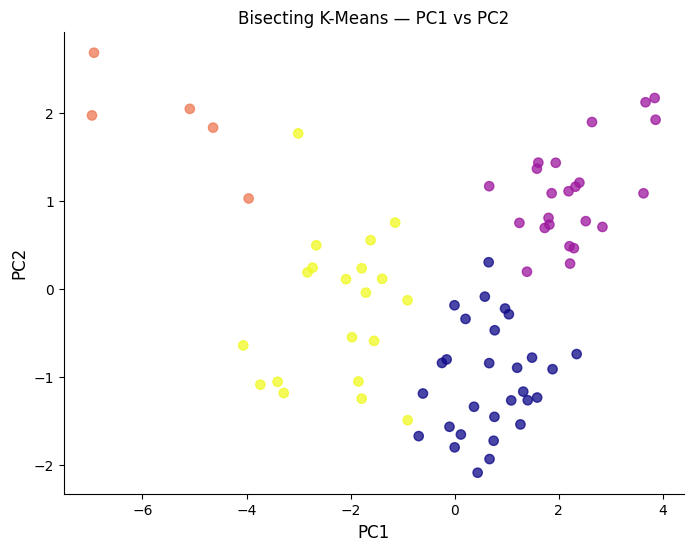

In [92]:
_, bkm_labels = fit_bisecting_kmeans(X, n_clusters=4)
print('BKM sizes:', dict(zip(*np.unique(bkm_labels, return_counts=True))))
plot_clustering(X, 'PC1', 'PC2', bkm_labels)
plt.title('Bisecting K-Means — PC1 vs PC2')
plt.show()

## 3 — DBSCAN

Recommended eps: 3.4347  (min_samples=7, num_std=3.0)


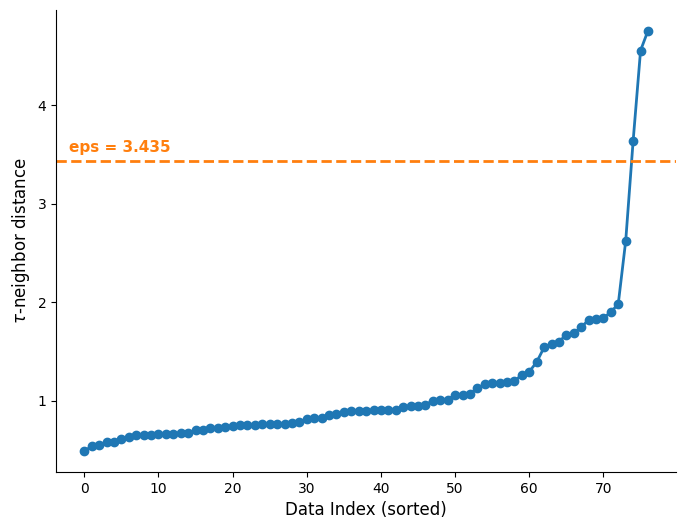

In [93]:
eps, distances = tune_eps(X, min_samples=7, num_std=3.0)
plot_neighbor_distances(distances, num_std=3.0)
plt.show()

In [94]:
_, db_labels = fit_dbscan(X, eps=eps, min_samples=7)
print('Labels found:', np.unique(db_labels))
d_summary(features, db_labels)

Clusters found: 1  |  Noise points: 0
Labels found: [0]


,avg_finish_position,avg_grid_position,avg_points_per_race,win_rate,podium_rate,dnf_rate,avg_fastest_lap_speed,avg_best_quali_time,n_drivers
Cluster 0,12.264035,12.338722,2.409499,0.028389,0.09112,0.613596,203.327532,88.150152,77
Overall,12.264035,12.338722,2.409499,0.028389,0.09112,0.613596,203.327532,88.150152,77


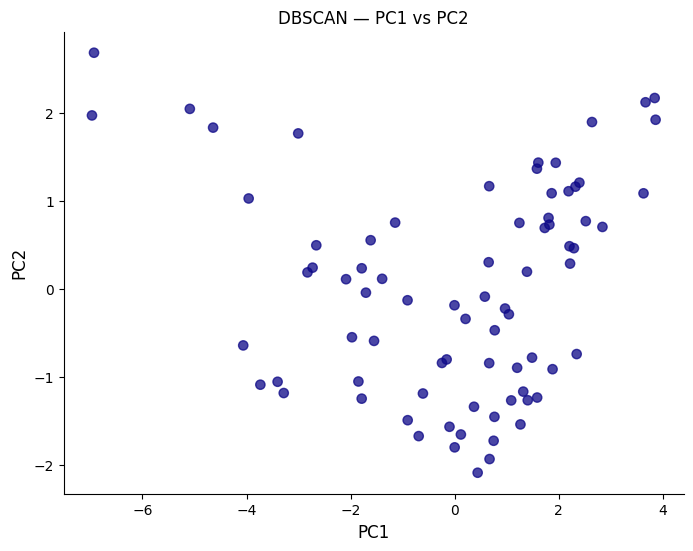

In [95]:
plot_clustering(X, 'PC1', 'PC2', db_labels)
plt.title('DBSCAN — PC1 vs PC2')
plt.show()

## 4 — Who is in each cluster? (K-Means)

In [96]:
import pandas as pd
driver_clusters = meta.copy()
driver_clusters['cluster'] = km_labels
for c in sorted(driver_clusters['cluster'].unique()):
    names = driver_clusters[driver_clusters['cluster'] == c]['driver_name'].tolist()
    print(f'\nCluster {c} ({len(names)} drivers):')
    print(', '.join(names))


Cluster 0 (23 drivers):
Heikki Kovalainen, Timo Glock, Adrian Sutil, Vitantonio Liuzzi, Pedro de la Rosa, Narain Karthikeyan, Mika Salo, Sébastien Buemi, Jaime Alguersuari, Kamui Kobayashi, Vitaly Petrov, Bruno Senna, Pastor Maldonado, Paul di Resta, Jean-Éric Vergne, Charles Pic, Max Chilton, Esteban Gutiérrez, Jules Bianchi, Marcus Ericsson, Felipe Nasr, Jolyon Palmer, Pascal Wehrlein

Cluster 1 (5 drivers):
Lewis Hamilton, Sebastian Vettel, Michael Schumacher, Mika Häkkinen, Max Verstappen

Cluster 2 (30 drivers):
Nick Heidfeld, Kazuki Nakajima, Takuma Sato, Jarno Trulli, Giancarlo Fisichella, Alexander Wurz, Christijan Albers, Christian Klien, Tiago Monteiro, Jacques Villeneuve, Olivier Panis, Heinz-Harald Frentzen, Jos Verstappen, Jean Alesi, Eddie Irvine, Romain Grosjean, Nico Hülkenberg, Kevin Magnussen, Daniil Kvyat, Stoffel Vandoorne, Esteban Ocon, Lance Stroll, Antonio Giovinazzi, Pierre Gasly, Alexander Albon, Nicholas Latifi, Yuki Tsunoda, Mick Schumacher, Guanyu Zhou, Log